### Load Model

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1,2"
import torch
import sys
sys.path.insert(0, "/home/lmeyers/rep_learn_scripts/dino_patch")
from patch_embedding import *

preprocessor, model = load_dinov3_model("facebook/dinov3-vitl16-pretrain-lvd1689m", device='cuda')

Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

### Load Image, and Resize to fit in GPU

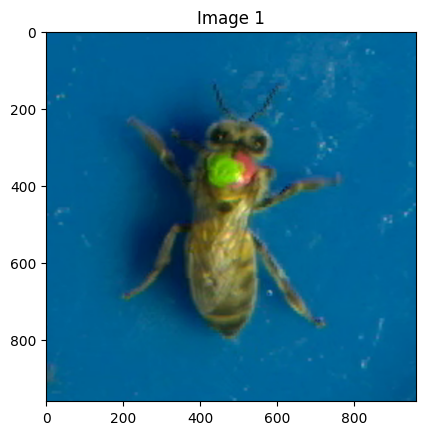

Cropped image sizes:
(960, 960)


In [5]:
from PIL import Image
from matplotlib import pyplot as plt
sys.path.insert(0, "/home/lmeyers/rep_learn_scripts/")
from utils.image_utils import *



IMAGE_PATHs = ["/mnt/data/andrea_bees/images/young-adults-blue-white-in-lab-1-32_batch_1.mp4.track000531.frame070271.png"]#"/home/lmeyers/beefeeder_inference/rio-grande/unrotated/bf-rg_2025-04-10_02.cfr.mp4/bf-rg_2025-04-10_02.cfr.mp4.T000309_F015029.jpg",
               #"/home/lmeyers/random_images_and_figures/Screenshot 2026-02-20 121815.png",
               #"/home/lmeyers/random_images_and_figures/Screenshot 2026-04-06 123957.png",
               #"/home/lmeyers/random_images_and_figures/honeybee1-800.jpg"]
#IMAGE_PATH = "/home/lmeyers/random_images_and_figures/Screenshot 2025-04-17 154938.png"#  # change it

#image_cropped = crop_square(IMAGE_PATH, crop_size=900, translation=(0,0))
cropped_images = []

max_image_size = (960, 960)
for i, IMAGE_PATH in enumerate(IMAGE_PATHs):
    image = Image.open(IMAGE_PATH).convert("RGB")
    #image_cropped = image.crop((750, 1450, 1050,1750))  # crop to square using the width of the image
    # crop to multiple of 16 
    scale_factor = 3

    #crop to square using the width or height of the image
    if i == 3:
        x_offset = 125
        image_cropped = image.crop((x_offset, 0, x_offset + min(image.width - x_offset, image.height), min(image.width - x_offset, image.height)))
    else:
        image_cropped = image.crop((0, 0, min(image.width, image.height), min(image.width, image.height)))
    if i == 0:
        #flip horizontally
        image_cropped = image_cropped.transpose(Image.FLIP_LEFT_RIGHT)

    #scale up to have more pixels, but keep the aspect ratio
    scale_factor = min(max_image_size[0] / image_cropped.width, max_image_size[1] / image_cropped.height)
    image_cropped = image_cropped.resize((int(image_cropped.width * scale_factor), int(image_cropped.height * scale_factor)), resample=Image.BICUBIC)
    
    # Crop to multiple of 16 for ViT-L16
    image_cropped = image_cropped.crop((0, 0, image_cropped.width - (image_cropped.width % 16), image_cropped.height - (image_cropped.height % 16)))
    
    #image_size = (image_cropped.width, image_cropped.height)
    #max_image_size = (max(max_image_size[0], image_size[0]), max(max_image_size[1], image_size[1]))
    cropped_images.append(image_cropped)
    plt.imshow(image_cropped)
    plt.title(f"Image {i+1}")
    plt.show()

print("Cropped image sizes:")
print(max_image_size)


In [6]:
noise_image = Image.fromarray(np.random.randint(0, 255, (max_image_size[1], max_image_size[0], 3), dtype=np.uint8))
cropped_images.append(noise_image)

### Background Removal with SAM 

In [116]:
## Run sam2 background removal
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

sam2_checkpoint = "/home/lmeyers/beefeeder_inference/samv2/sam2.1_hiera_large.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"

device= "cuda"
sam2_model = build_sam2(model_cfg, sam2_checkpoint, device=device)

predictor = SAM2ImagePredictor(sam2_model)

In [7]:
# Predict using the center of the image 
def predict_using_center(predictor, image_cropped):
    image_width, image_height = image_cropped.size
    center_point = (image_width // 2, image_height // 2)
    center_point = (center_point[0], center_point[1] )  # (x, y) format for SAM
    predictor.set_image(image_cropped)
    masks, scores, _ = predictor.predict(point_coords=[center_point], point_labels=[1], multimask_output=False)
    return masks, scores

def predict_custom_points(predictor, image_cropped, points):
    predictor.set_image(image_cropped)
    masks, scores, _ = predictor.predict(point_coords=points, point_labels=[1]*len(points), multimask_output=False)
    return masks, scores

#masks, scores = predict_using_center(predictor, image_cropped)
# Convert masks to binary and apply to the image
def display_masked_image(image_cropped, masks):
    binary_mask = masks[0].astype(bool)
    image_array = np.array(image_cropped)
    background_removed_image = np.zeros_like(image_array)
    background_removed_image[binary_mask] = image_array[binary_mask]
    background_removed_image_pil = Image.fromarray(background_removed_image)
    plt.imshow(background_removed_image_pil)
    plt.axis('off')
    plt.show()
    return background_removed_image_pil, binary_mask
#display_masked_image(image_cropped, masks)


In [8]:
# RUN SAM2
points =[[],[]]#[[(400, 600)],
          #[(400, 450), (700, 500)],  
          #[(100, 800)],
          # [(300,250)]]

background_removed_images = []
all_masks = []
for i, (image, points_for_image) in enumerate(zip(cropped_images, points)):
    if points_for_image == []:
        mask = np.ones((image.height, image.width), dtype=bool)  # Keep the whole image if no points provided
        background_removed_image = image.copy()
        background_removed_images.append(background_removed_image)
        all_masks.append(mask)
        continue
    masks, scores = predict_custom_points(predictor, image, points_for_image)
    if i == 2:
        #for last image invert mask
        masks = 1 - masks
    print(f"Image {i+1} - Points: {points_for_image}, Scores: {scores}")
    background_removed_image, binary_mask = display_masked_image(image, masks)
    background_removed_images.append(background_removed_image)
    all_masks.append(binary_mask)

### Forward pass through model

IF you get out of memory error crop some more

In [9]:
# Get the patch embeddings with loop cause not same size
patches = []
device="cuda"
for image in background_removed_images:
     class_embs, patch_embs = get_dinov3_class_patch_embeddings(image, preprocessor, model, device=device)
     print("Class embedding shape:", class_embs.shape)
     patches.append(patch_embs)



Class embedding shape: torch.Size([1, 1024])
Class embedding shape: torch.Size([1, 1024])


### Similarity Map Vis

torch.Size([1, 3600])


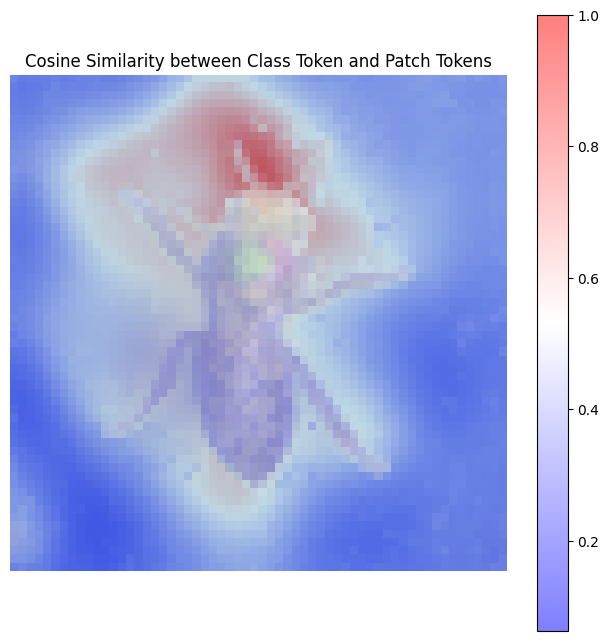

In [18]:
#calculate similarity between class token and patches
#grid_h, grid_w = get_grid_size_from_patch_embeddings(patches)

grid_h, grid_w = int(np.floor(image_cropped.size[1] / 16)), int(np.floor(image_cropped.size[0] / 16))  # for ViT-L16, patch size is 16x16

similarity = calc_similarities_to_patches(patches[0], patches[0][:,690,:])  # (N, N) similarity of each patch to the class token patch

print(similarity.shape)

display_similarity_map(image_cropped, similarity, (grid_h, grid_w))


## PCA Vis

In [10]:
# take out all patches that correspond to completely black areas in the image

def get_patches_from_mask(mask, patch_size=16):
    #need to invert mask so that True is for black pixels
    print(mask.shape, mask.dtype)
    mask = ~mask.astype(bool)
    H, W = mask.shape
    grid_h = H // patch_size
    grid_w = W // patch_size
    patches = np.zeros((grid_h, grid_w), dtype=bool)
    for i in range(grid_h):
        for j in range(grid_w):
            patch = mask[i*patch_size:(i+1)*patch_size, j*patch_size:(j+1)*patch_size]
            patches[i, j] = patch.all()  # True if all pixels in the patch are black
    return patches

all_black_mask_patches = [] 
for foreground_mask in all_masks:
    black_mask_patches = get_patches_from_mask(foreground_mask, patch_size=16)  # (N_patches,) boolean array indicating which patches are black
    print(black_mask_patches.shape)
    all_black_mask_patches.append(black_mask_patches)

(960, 960) bool
(60, 60)
(960, 960) bool
(60, 60)


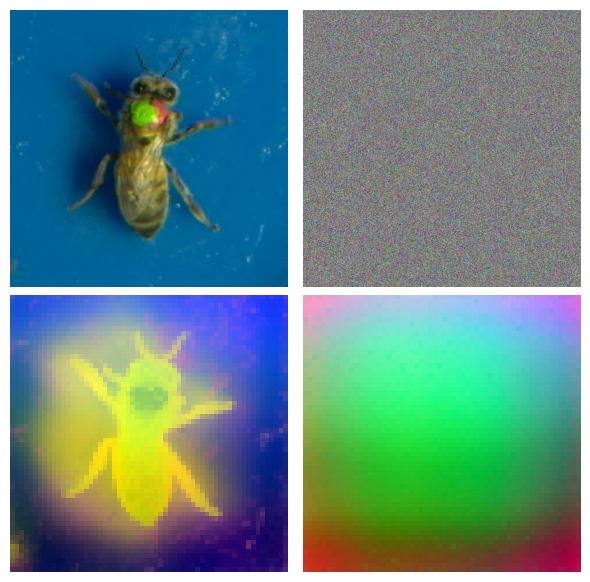

In [11]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# patch_embeds: shape (num_patches, embed_dim)
# patch_grid: (H, W) grid shape of patches


def plot_pca_from_patches_single_image(image_cropped, patches, black_mask_patches):
    patch_embeds_np = patches.squeeze(0).detach().cpu().numpy()

    # mask for black patches: (grid_h, grid_w) -> (N,)
    black_mask_patches_flat = black_mask_patches.reshape(-1)

    # keep only non-black patches for PCA
    patch_embeds_non_black = patch_embeds_np[~black_mask_patches_flat]

    pca = PCA(n_components=3)
    patch_pca = pca.fit_transform(patch_embeds_non_black)

    # normalize to [0, 1]
    patch_pca -= patch_pca.min(axis=0, keepdims=True)
    patch_pca /= (patch_pca.max(axis=0, keepdims=True) + 1e-8)

    # restore full patch map (black patches remain 0)
    patch_pca_full = np.zeros((patch_embeds_np.shape[0], 3), dtype=np.float32)
    patch_pca_full[~black_mask_patches_flat] = patch_pca

    # reshape to patch grid and visualize
    grid_h, grid_w = int(np.floor(image_cropped.size[1] / 16)), int(np.floor(image_cropped.size[0] / 16))  # for ViT-L16, patch size is 16x16
    patch_img = patch_pca_full.reshape(grid_h, grid_w, 3)
    plt.figure(figsize=(6, 6))
    plt.imshow(patch_img)
    plt.axis("off")
    plt.title("Patch Embeddings (PCA RGB)")
    plt.show()

    return pca, patch_pca_full

def fit_pca_on_patches(patch_list, black_mask_patches_list):
    all_non_black_patches = []
    for patches, black_mask_patches in zip(patch_list, black_mask_patches_list):
        patch_embeds_np = patches.squeeze(0).detach().cpu().numpy()
        black_mask_patches_flat = black_mask_patches.reshape(-1)
        all_non_black_patches.append(patch_embeds_np[~black_mask_patches_flat])
    
    all_non_black_patches = np.concatenate(all_non_black_patches, axis=0)

    #fit pca on all non black patches
    pca = PCA(n_components=3)
    pca.fit(all_non_black_patches)

    return pca

def transform_and_display(image_list,patches_list,black_mask_patches_list, pca):
    fig, axes = plt.subplots(2, len(image_list), figsize=(3*len(image_list), 6), gridspec_kw={'hspace': 0})
    if len(image_list) == 1:
        axes = axes.reshape(2, 1)
    for i, (image_cropped, patches, black_mask_patches) in enumerate(zip(image_list, patches_list, black_mask_patches_list)):
        patch_embeds_np = patches.squeeze(0).detach().cpu().numpy()
        black_mask_patches_flat = black_mask_patches.reshape(-1)
        patch_embeds_non_black = patch_embeds_np[~black_mask_patches_flat]

        patch_pca = pca.transform(patch_embeds_non_black)

        # normalize to [0, 1]
        patch_pca -= patch_pca.min(axis=0, keepdims=True)
        patch_pca /= (patch_pca.max(axis=0, keepdims=True) + 1e-8)

        # restore full patch map (black patches remain 0)
        patch_pca_full = np.zeros((patch_embeds_np.shape[0], 3), dtype=np.float32)
        patch_pca_full[~black_mask_patches_flat] = patch_pca

        grid_h, grid_w = int(np.floor(image_cropped.size[1] / 16)), int(np.floor(image_cropped.size[0] / 16))  # for ViT-L16, patch size is 16x16
        # reshape to patch grid and visualize
        patch_img = patch_pca_full.reshape(grid_h, grid_w, 3)
        axes[0][i].imshow(image_cropped)
        axes[0][i].axis("off")
        #axes[0][i].set_title(f"Image {i+1}")
        axes[1][i].imshow(patch_img)
        axes[1][i].axis("off")
        #axes[1][i].set_title(f"PCA Visualization {i+1}")
    plt.tight_layout()
    plt.show()


pca = fit_pca_on_patches(patches, all_black_mask_patches)
transform_and_display(cropped_images, patches, all_black_mask_patches, pca)



Text(0.5, 1.0, 'Query Image')

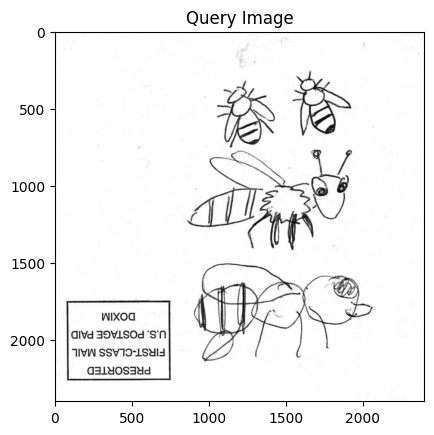

In [127]:
# Try with a new image 
query_image_path = "/home/lmeyers/random_images_and_figures/BRWF8DA0C2E0A59_000923.jpg"
query_image = Image.open(query_image_path).convert("RGB")
query_image_cropped = query_image.crop((0, 0, 1200,1200))
scale_factor = 2
query_image_cropped = query_image_cropped.resize((int(query_image_cropped.width * scale_factor), int(query_image_cropped.height * scale_factor)), resample=Image.BICUBIC)
#crop to multiple of 16 for ViT-L16
query_image_cropped = query_image_cropped.crop((0, 0, query_image_cropped.width - (query_image_cropped.width % 16), query_image_cropped.height - (  query_image_cropped.height % 16)))
plt.imshow(query_image_cropped)
plt.title("Query Image")

In [128]:
# Get the patch embeddings
class_embs, patch_embs = get_dinov3_class_patch_embeddings(query_image_cropped, preprocessor, model, device=device)
print("Class embedding shape:", class_embs.shape)
print("Patch embedding shape:", patch_embs.shape)

Class embedding shape: torch.Size([1, 1024])
Patch embedding shape: torch.Size([1, 22500, 1024])


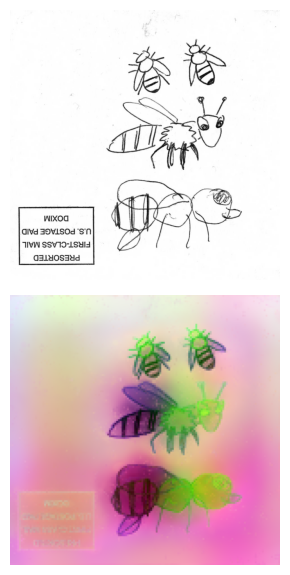

: 

In [ ]:
# show PCA visualization of the new image using the PCA fitted on the previous images
query_h, query_w = int(np.floor(query_image_cropped.size[1] / 16)), int(np.floor(query_image_cropped.size[0] / 16))
no_mask = np.zeros((query_h, query_w), dtype=bool)
transform_and_display([query_image_cropped],
 [patch_embs], 
 [no_mask], pca)